# Plotting solution of V and W

Plot solved `V` and `W` from `VWgrid` outputs.

- Loads `VWgrid_h{h}_eps{eps}.pkl` and `VWmeta_h{h}_eps{eps}.pkl`
- Aligns each model with the background radius grid
- Produces all-model grid plots and focused single-model plots


In [1]:
# Plot style
import matplotlib as mpl
# mpl.rcParams["font.family"] = "CMU Serif"


In [2]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd().resolve().parent  # .../high_bg_order_sol
if BASE.name != "high_bg_order_sol":
    BASE = Path.cwd().resolve()

CFG_PATH = BASE / "config" / "h_eps_config.pkl"
with open(CFG_PATH, "rb") as f:
    cfg = pickle.load(f)

h_tok = str(cfg["h"])
eps_tok = str(cfg["eps"])
target_dir = BASE / "numpy_grid" / f"h{h_tok}_eps{eps_tok}"

print("BASE      :", BASE)
print("target_dir:", target_dir)


BASE      : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol
target_dir: /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3


In [3]:
def _patch_numpy_pickle_modules():
    """
    Compatibility shim for pickle files created with a NumPy build
    that stores internals under numpy._core.*
    """
    try:
        import numpy.core as np_core
        import numpy.core.numeric as np_core_numeric
        sys.modules.setdefault("numpy._core", np_core)
        sys.modules.setdefault("numpy._core.numeric", np_core_numeric)
    except Exception:
        pass


def load_pickle_compat(path):
    _patch_numpy_pickle_modules()
    with open(path, "rb") as f:
        return pickle.load(f)


r_path = target_dir / f"RGrid_h{h_tok}_eps{eps_tok}.pkl"
if not r_path.exists():
    alt = target_dir / f"Rgrid_h{h_tok}_eps{eps_tok}.pkl"
    if alt.exists():
        r_path = alt

vw_path = target_dir / f"VWgrid_h{h_tok}_eps{eps_tok}.pkl"
vw_meta_path = target_dir / f"VWmeta_h{h_tok}_eps{eps_tok}.pkl"

RGrid = load_pickle_compat(r_path)
VWGrid = load_pickle_compat(vw_path)
VWMeta = load_pickle_compat(vw_meta_path)

records = VWMeta.get("records", []) if isinstance(VWMeta, dict) else []
n_models = min(len(RGrid), len(VWGrid))

print("Loaded models:", n_models)
print("VW meta timestamp:", VWMeta.get("meta", {}).get("timestamp", "N/A"))


Loaded models: 25
VW meta timestamp: 2026-03-11T09:11:45


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_9712/1621874837.py:18: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)


In [4]:
def grid_shape(n):
    if n <= 5:
        return 1, n
    if n <= 10:
        return 2, 5
    if n <= 15:
        return 3, 5
    if n <= 20:
        return 4, 5
    if n <= 25:
        return 5, 5
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def get_vw_arrays(star_id):
    sol = np.asarray(VWGrid[star_id], dtype=float)
    r_all = np.asarray(RGrid[star_id], dtype=float)

    n_from_sol = len(sol)
    n_from_r = len(r_all)
    n = min(n_from_sol, n_from_r)

    if star_id < len(records):
        surface_idx = int(records[star_id].get("surface_index", n))
        if surface_idx > 0:
            n = min(n, surface_idx)

    r = r_all[:n]
    v = sol[:n, 0]
    w = sol[:n, 1]

    mask = np.isfinite(r) & np.isfinite(v) & np.isfinite(w)
    return r[mask], v[mask], w[mask]


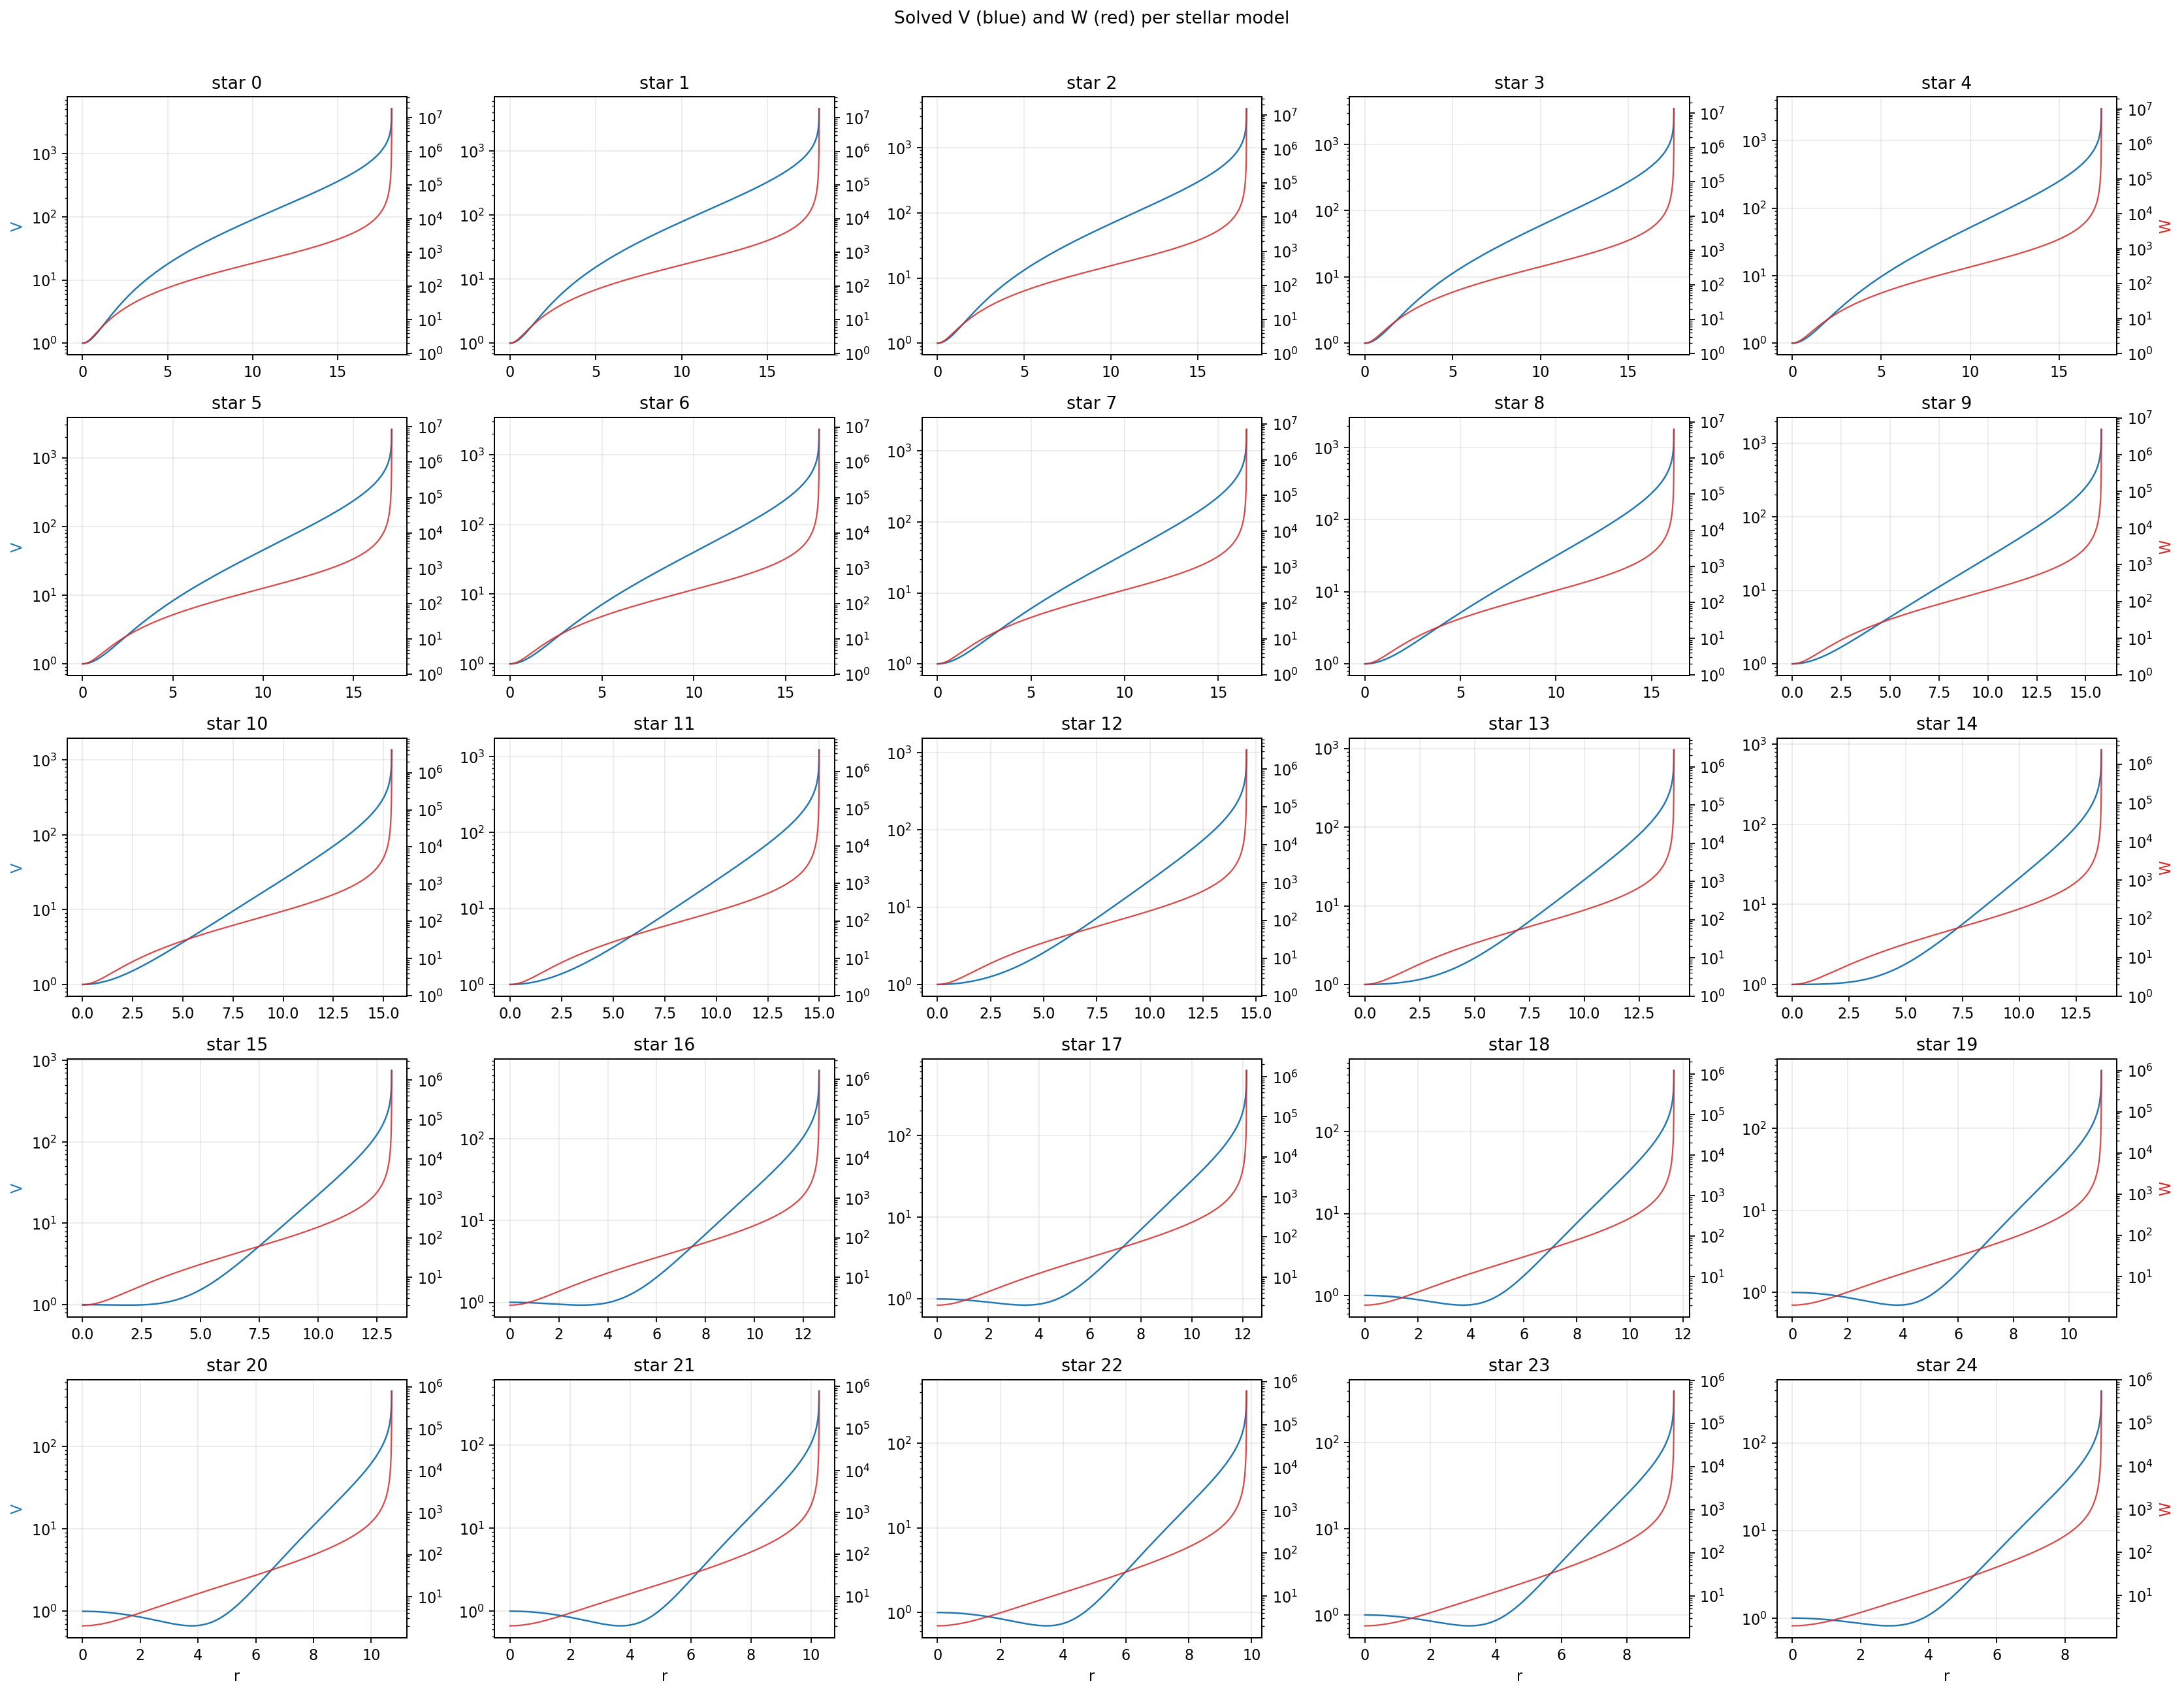

In [10]:
# All-model overview: V and W on twin y-axes
n_plot = n_models
rows, cols = grid_shape(n_plot)
fig, axs = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.2 * rows), dpi=160)
axs = np.atleast_1d(axs).reshape(rows, cols)

for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot:
        ax.axis("off")
        continue

    r, v, w = get_vw_arrays(i)
    ax2 = ax.twinx()

    ax.plot(r, v, color="tab:blue", lw=1.1)
    ax2.plot(r, np.abs(w), color="tab:red", lw=1.0, alpha=0.85)

    ax.set_yscale("log")
    ax2.set_yscale("log")

    ax.set_title(f"star {i}")
    ax.grid(alpha=0.25)

    if i % cols == 0:
        ax.set_ylabel("V", color="tab:blue")
    if i % cols == cols - 1:
        ax2.set_ylabel("W", color="tab:red")
    if i // cols == rows - 1:
        ax.set_xlabel("r")

fig.suptitle("Solved V (blue) and W (red) per stellar model", y=1.01)
fig.tight_layout()
plt.show()


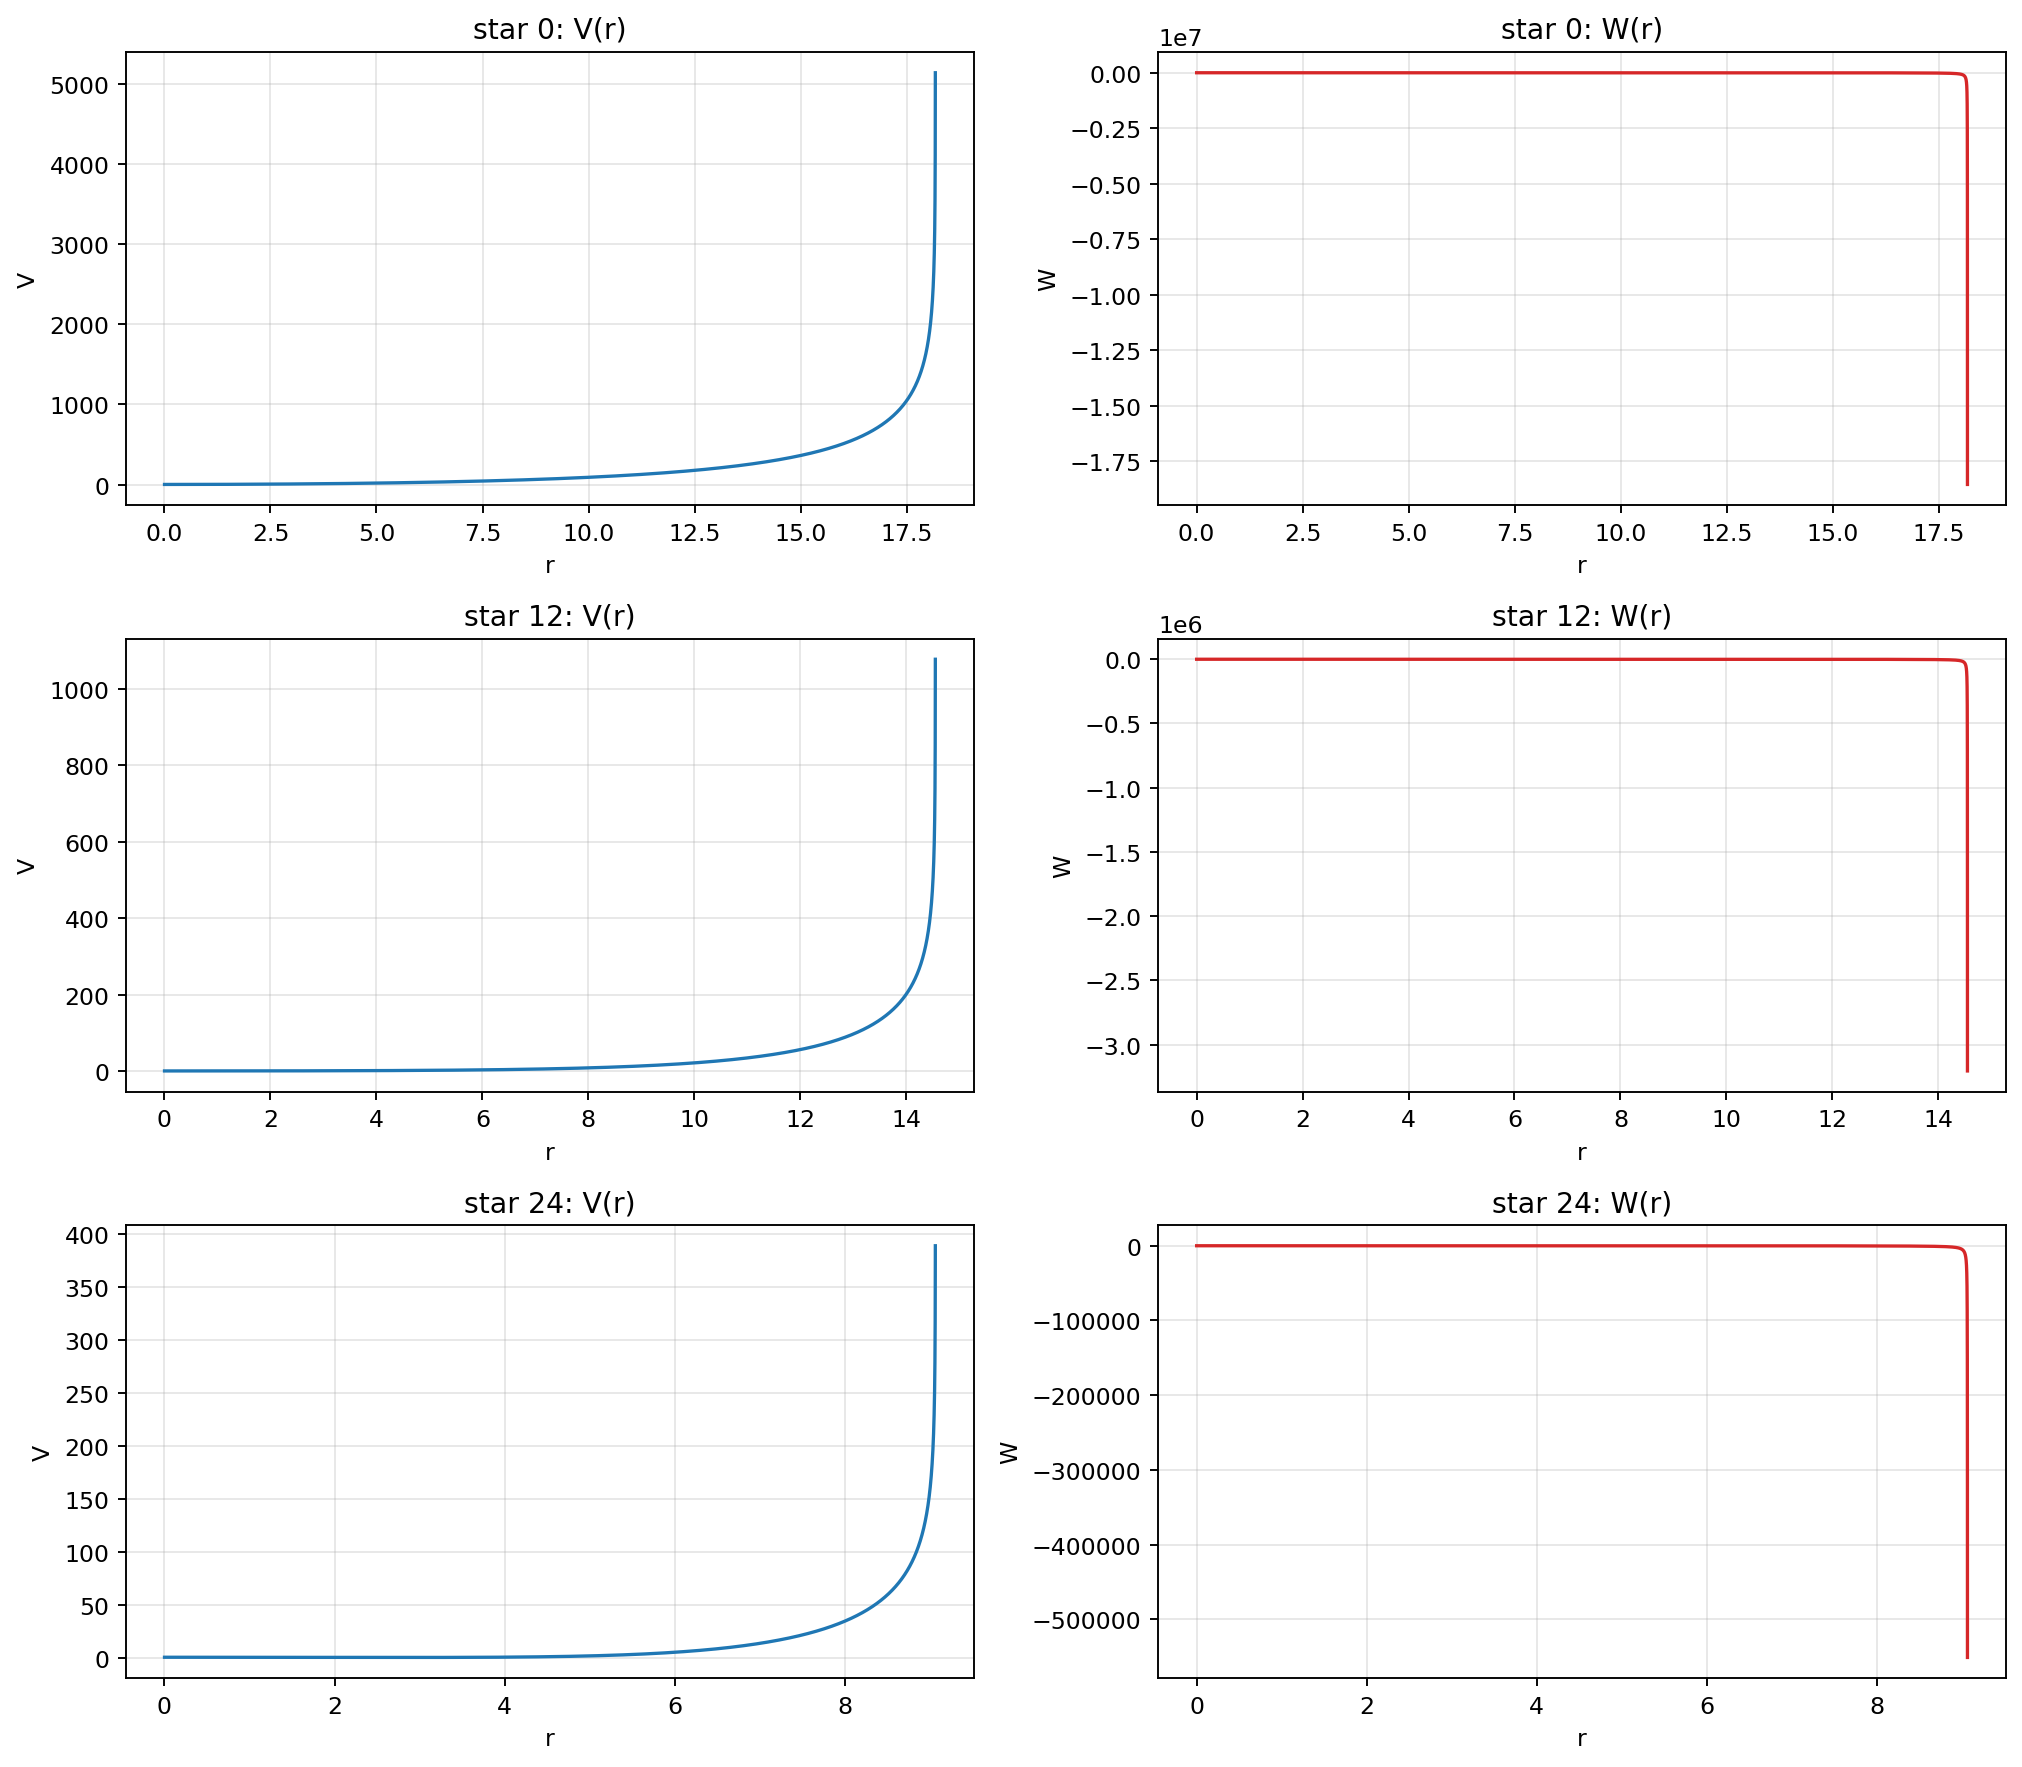

In [6]:
# Focused diagnostics for representative models
selected = sorted(set([0, n_models // 2, n_models - 1]))
fig, axs = plt.subplots(len(selected), 2, figsize=(12, 3.5 * len(selected)), dpi=170)
axs = np.atleast_2d(axs)

for row, sid in enumerate(selected):
    r, v, w = get_vw_arrays(sid)

    axs[row, 0].plot(r, v, color="tab:blue", lw=1.4)
    axs[row, 0].set_title(f"star {sid}: V(r)")
    axs[row, 0].set_xlabel("r")
    axs[row, 0].set_ylabel("V")
    axs[row, 0].grid(alpha=0.3)

    axs[row, 1].plot(r, w, color="tab:red", lw=1.4)
    axs[row, 1].set_title(f"star {sid}: W(r)")
    axs[row, 1].set_xlabel("r")
    axs[row, 1].set_ylabel("W")
    axs[row, 1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


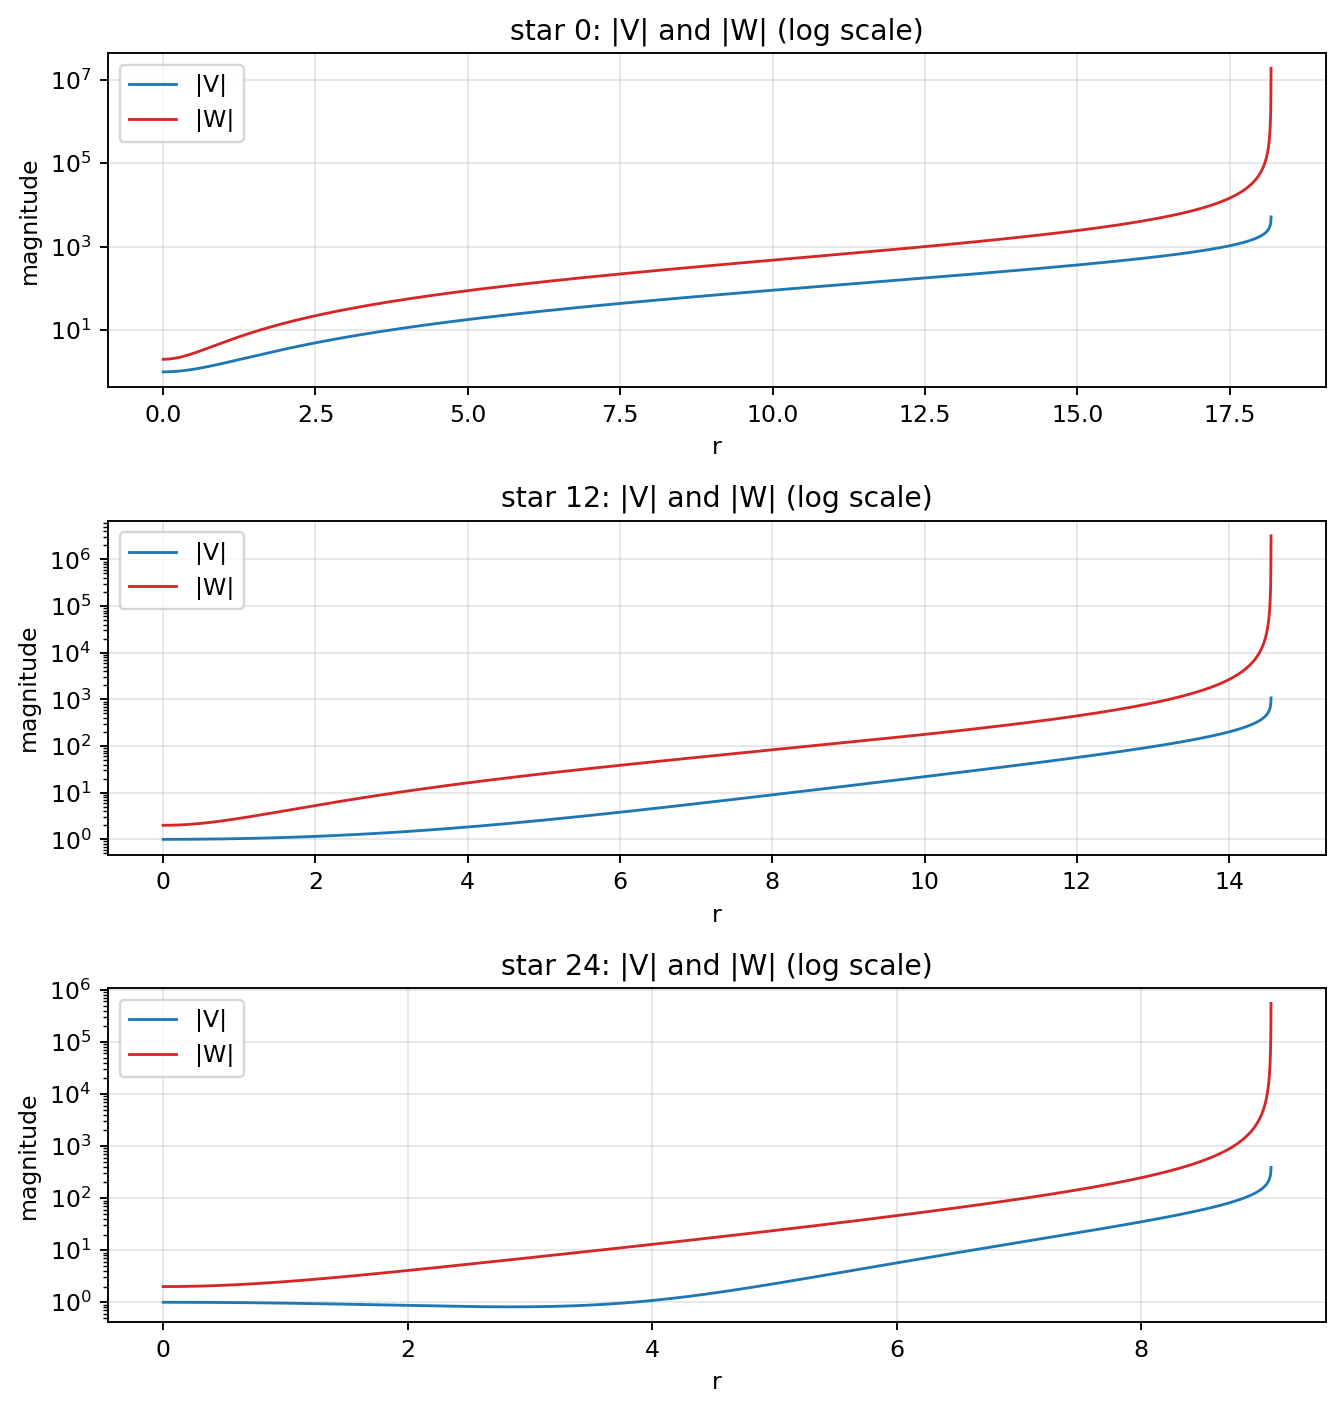

In [7]:
# Optional magnitude view (absolute value, log y)
fig, axs = plt.subplots(len(selected), 1, figsize=(8, 2.8 * len(selected)), dpi=170)
axs = np.atleast_1d(axs)

for row, sid in enumerate(selected):
    r, v, w = get_vw_arrays(sid)
    axs[row].plot(r, np.abs(v), color="tab:blue", lw=1.2, label="|V|")
    axs[row].plot(r, np.abs(w), color="tab:red", lw=1.2, label="|W|")
    axs[row].set_yscale("log")
    axs[row].set_title(f"star {sid}: |V| and |W| (log scale)")
    axs[row].set_xlabel("r")
    axs[row].set_ylabel("magnitude")
    axs[row].grid(alpha=0.3)
    axs[row].legend()

fig.tight_layout()
plt.show()
